## Task #4: Plot Example Signals per Category
Goal: Visually inspect example vibration signals from each class (Normal, InnerRaceFault, OuterRaceFault) to check for differences or things to account for later.

In [6]:
from pathlib import Path
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
print("Reading from:", DATA_DIR.resolve())

def load_split(split):
    mat = scipy.io.loadmat(DATA_DIR / f"{split}.mat")
    X = mat[f"{split}Data"]
    y = [str(label[0]) for label in mat[f"{split}Labels"].flatten()]
    return X, y

X_train, y_train = load_split("train")
CATEGORIES = ["Normal", "InnerRaceFault", "OuterRaceFault"]
SAMPLE_RATE = 48828  # Hz, from data README

Reading from: C:\Users\Sahana\MathWorks-1D-unlocking-embedded-ai-through-efficient-compression\data


### One example signal per class

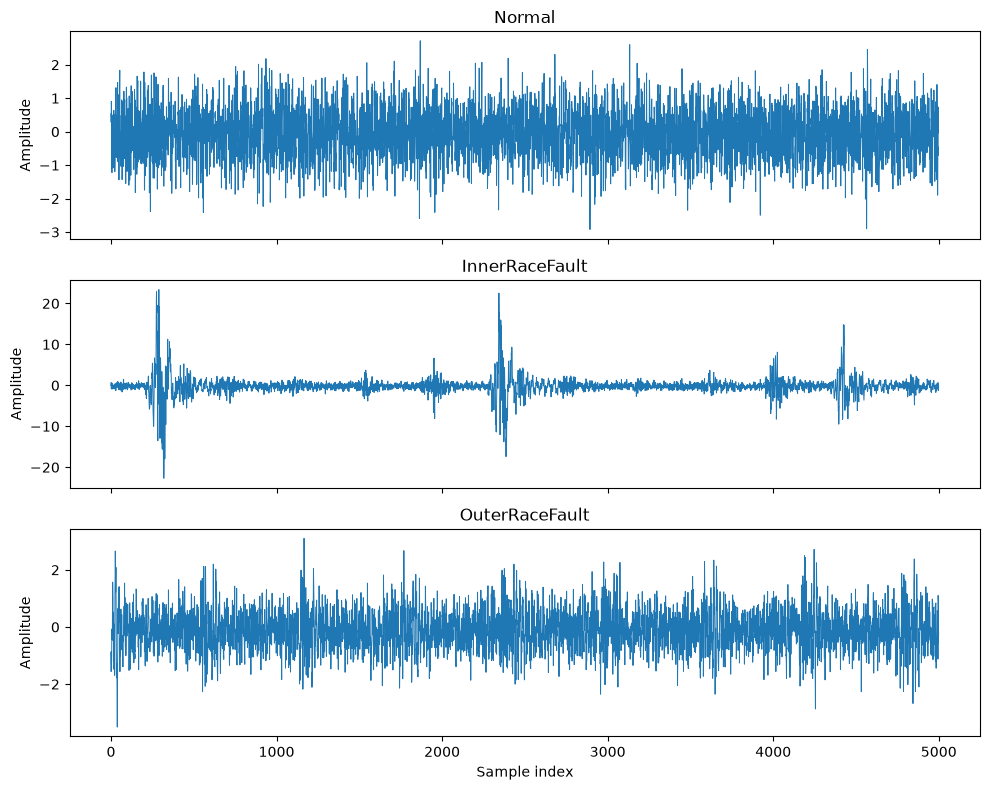

In [3]:
fig, axes = plt.subplots(len(CATEGORIES), 1, figsize=(10, 8), sharex=True)

for ax, cls in zip(axes, CATEGORIES):
    i = y_train.index(cls)
    ax.plot(X_train[i], linewidth=0.7)
    ax.set_title(cls)
    ax.set_ylabel("Amplitude")

axes[-1].set_xlabel("Sample index")
plt.tight_layout()
plt.show()

### Notes: One example signal per class

- **Normal:** Amplitude stays small, roughly -3 to 3. Just consistent background noise, no sharp spikes anywhere in the signal.
- **InnerRaceFault:** Amplitude spikes way higher, up to ~25. Clear sharp spikes appear periodically against an otherwise quiet baseline, this matches what we'd expect from a ball repeatedly rolling over the same damaged spot.
- **OuterRaceFault:** Amplitude stays in a similar range to Normal (-3 to 3), with a couple of slightly bigger bumps. Much harder to visually tell apart from Normal compared to InnerRaceFault.

### Multiple examples per class (checking consistency within a class)

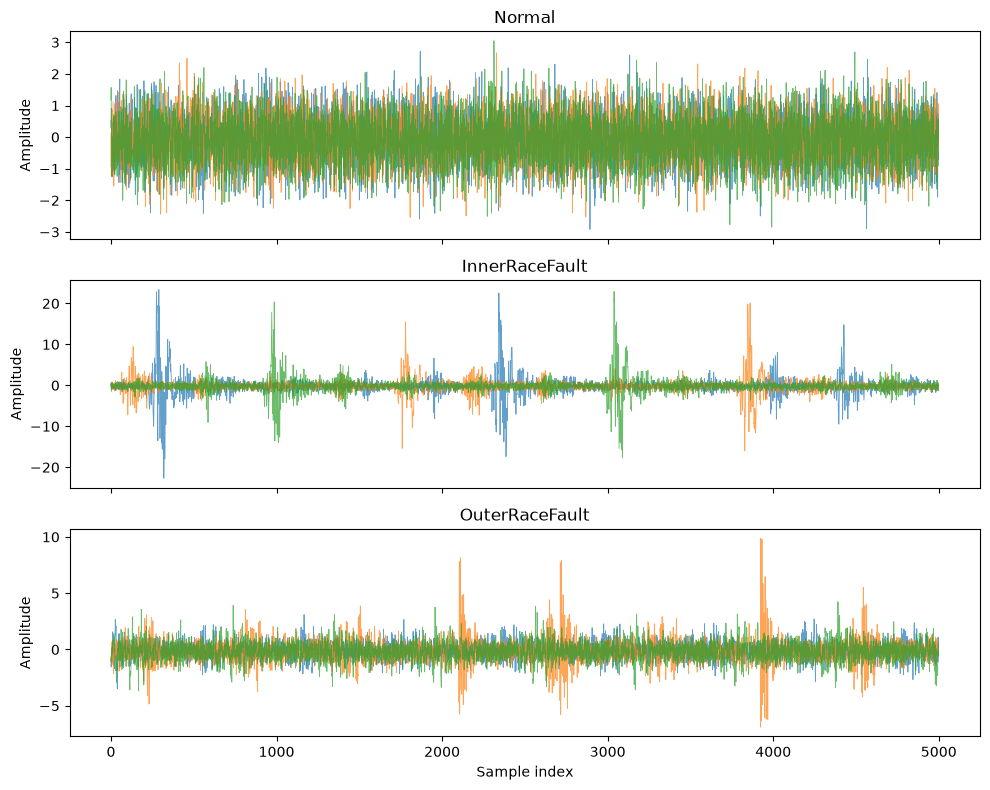

In [4]:
N_EXAMPLES = 3

fig, axes = plt.subplots(len(CATEGORIES), 1, figsize=(10, 8), sharex=True)

for ax, cls in zip(axes, CATEGORIES):
    idxs = [i for i, label in enumerate(y_train) if label == cls][:N_EXAMPLES]
    for i in idxs:
        ax.plot(X_train[i], linewidth=0.6, alpha=0.7)
    ax.set_title(cls)
    ax.set_ylabel("Amplitude")

axes[-1].set_xlabel("Sample index")
plt.tight_layout()
plt.show()

### Notes: Multiple examples overlaid per class

- **Normal:** All 3 examples look nearly identical in range and pattern, just noise the whole way through. Very consistent within the class.
- **InnerRaceFault:** All 3 examples show the same spike pattern (quiet baseline + periodic sharp spikes), though the spikes land at slightly different sample positions across examples. Confirms the spiking behavior isn't a one-off, it's characteristic of this class.
- **OuterRaceFault:** All 3 examples stay in a similar amplitude range to each other, with some examples showing slightly bigger bumps than others. Less visually distinct than InnerRaceFault, and closer to Normal in overall shape.

### FFT (Frequency Domain) for one example signal per class

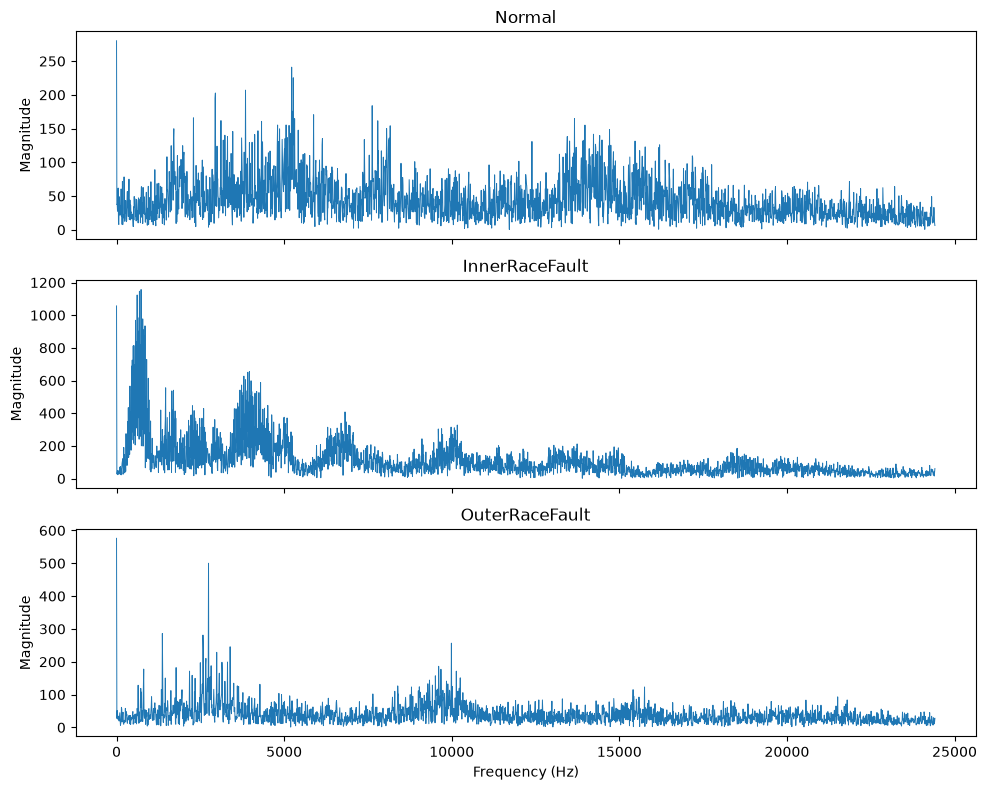

In [7]:
fig, axes = plt.subplots(len(CATEGORIES), 1, figsize=(10, 8), sharex=True)

for ax, cls in zip(axes, CATEGORIES):
    i = y_train.index(cls)
    signal = X_train[i]

    n = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_freqs = np.fft.rfftfreq(n, d=1/SAMPLE_RATE)
    fft_magnitude = np.abs(fft_vals)

    ax.plot(fft_freqs, fft_magnitude, linewidth=0.7)
    ax.set_title(cls)
    ax.set_ylabel("Magnitude")

axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

### Notes: FFT per class

- **Normal:** Low overall magnitude (~250 max). Energy is spread out across the whole frequency range with no clear dominant peak, looks broadband/noisy rather than concentrated anywhere.

- **InnerRaceFault:** Much higher magnitude, up to ~1150. Strong concentration at low frequencies (0-2000 Hz), with a smaller secondary bump around 3000-4000 Hz. Energy drops off steadily as frequency increases. This matches the sharp periodic spikes we saw in the time-domain plot.

- **OuterRaceFault:** Magnitude peaks around ~600. Has a distinct spike around 2500-3000 Hz, and a smaller bump near 10000 Hz that neither Normal nor InnerRaceFault show in the same place.

**Key takeaway:** OuterRaceFault and Normal looked nearly identical in the raw time-domain signal, but in the frequency domain, OuterRaceFault has a distinct peak around 2500-3000 Hz that Normal doesn't have. This suggests frequency-domain features could help the model separate these two classes, even though they're hard to tell apart from raw amplitude alone.